# Lever 4 -- Buffer / over-hedge multiplier

Self-contained (own data load, own formulas -- nothing imported from `deprecated/` or any
other notebook).

**Question**: should the hedge be sized to slightly *more* than the computed target
dollar-delta, as a margin of safety against model/estimation error (BS delta is only an
approximation, beta is a trailing estimate, not a forward guarantee)?

**Frozen from Levers 1-3** (not re-decided here): the `cost_benefit` instrument rule,
moneyness bucket = 20% OTM, target DTE = 180, roll trigger DTE = 7, coverage band =
tight (10%) -- Lever 3's held-out-validated winner.

**What's new here**: a multiplier applied to target dollar-delta at every sizing event
-- both DTE-triggered rolls and band-triggered corrections -- swept over
{0.5, 1.0, 1.5, 2.0}. 1.0 is the no-buffer baseline (should reproduce Lever 3's tight-band
winner exactly).

**Selection methodology**: same reasoning as Lever 3, applied from the start this time --
the train window is a pure decline, and an over-hedge buffer's main benefit (protecting
against a hedge that's undersized relative to a fast-growing short exposure) only shows
up in a rally, exactly like the coverage band. Ranking by train Sharpe alone would bias
against any buffer > 1.0 almost by construction (more contracts bought, no offsetting
benefit in a decline). So: gate on non-negative Sharpe and MaxDD >= -50% on both held-out
windows, then rank survivors by the **worst-case composite score**
(`sharpe + cagr + maxdd`, minimum across train/testA/testB) -- not train Sharpe alone.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]
DATA = ROOT / "data"
%matplotlib inline

## Load data (fresh parse, same conventions as `00_foundation_sandbox.ipynb`)

In [2]:
tsla_raw = pd.read_excel(DATA / "Excel3_Underlying_Data.xlsx", sheet_name="TSLA", header=10)
tsla_raw["Date"] = pd.to_datetime(tsla_raw["Date"])
tsla_spot = tsla_raw.set_index("Date")["Close"].sort_index().dropna()

tsll_raw = pd.read_excel(DATA / "TSLL_ohlcv.xlsx", sheet_name="TSLL")
tsll_raw["Date"] = pd.to_datetime(tsll_raw["Date"])
tsll_spot = tsll_raw.set_index("Date")["Close"].sort_index().dropna()

tsla_calls = pd.read_parquet(DATA / "processed" / "TSLA_calls_close.parquet")
tsll_calls = pd.read_parquet(DATA / "processed" / "TSLL_calls_close.parquet")

r_tsla = tsla_spot.pct_change().dropna()
r_tsll = tsll_spot.pct_change().dropna()
dates = r_tsla.index.intersection(r_tsll.index)
r_tsla, r_tsll = r_tsla.loc[dates], r_tsll.loc[dates]
tsla_spot, tsll_spot = tsla_spot.loc[dates], tsll_spot.loc[dates]

print(f"{len(dates):,} trading days, {dates.min().date()} -> {dates.max().date()}")

960 trading days, 2022-08-10 -> 2026-06-08


## Pre-indexed lookups (performance only)

In [3]:
tsla_calls_by_date = {d: g for d, g in tsla_calls.groupby("date")}
tsll_calls_by_date = {d: g for d, g in tsll_calls.groupby("date")}

tsla_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsla_calls.itertuples(index=False)}
tsll_price_lookup = {(r.raw_id, r.date): r.px_last for r in tsll_calls.itertuples(index=False)}

## Fresh formulas -- Black-Scholes delta, rolling vol/beta, contract selection, sizing, risk metrics

In [4]:
R_RF = 0.05              # stated assumption, not estimated (per project scope)
ESTIMATION_WINDOW = 21   # stated convention (~1 trading month), not tested/optimized

MONEYNESS_RANGES = {
    "ATM": (0.95, 1.05),
    "10% OTM": (1.05, 1.15),
    "20% OTM": (1.15, 1.25),
}


def bs_call_delta(S, K, T_years, r, sigma):
    """Black-Scholes European call delta = N(d1). Clipped to [0.01, 1.0]."""
    if T_years <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 1.0 if S > K else 0.01
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T_years) / (sigma * np.sqrt(T_years))
    return float(np.clip(norm.cdf(d1), 0.01, 1.0))


tsla_sigma = (r_tsla.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
tsll_sigma = (r_tsll.rolling(ESTIMATION_WINDOW).std() * np.sqrt(252)).ffill().bfill()
beta_tsll_vs_tsla = ((r_tsll.rolling(ESTIMATION_WINDOW).cov(r_tsla)
                      / r_tsla.rolling(ESTIMATION_WINDOW).var()).shift(1)).ffill().bfill()

assert tsla_sigma.isna().sum() == 0 and tsll_sigma.isna().sum() == 0 and beta_tsll_vs_tsla.isna().sum() == 0


def select_contract(calls_by_date, spot_series, date, moneyness_bucket, target_dte, max_dte):
    """Filter to the moneyness bucket, require a real fill, positive DTE within max_dte,
    pick the contract closest to target_dte. Moneyness is ALWAYS bounded."""
    day = calls_by_date.get(date)
    if day is None or day.empty:
        return None
    lo, hi = MONEYNESS_RANGES[moneyness_bucket]
    s = float(spot_series.loc[date])
    moneyness = day["strike"] / s
    dte = (day["expiry"] - date).dt.days
    mask = (
        (moneyness >= lo) & (moneyness < hi)
        & (dte > 0) & (dte <= max_dte)
        & day["px_last"].notna() & (day["px_last"] > 0)
        & day["px_volume"].notna() & (day["px_volume"] > 0)
    )
    candidates = day[mask]
    if candidates.empty:
        return None
    dte_c = (candidates["expiry"] - date).dt.days
    idx = (dte_c - target_dte).abs().idxmin()
    return candidates.loc[idx]


def size_position(row, spot_val, sigma_val, target_dollar_delta, date):
    """Delta-neutral contract count for a given target dollar-delta. CONTRACTS, not
    shares -- cost is always n_contracts * 100 * entry_price."""
    if row is None:
        return 0.0, float("inf"), 0.0
    entry = float(row["px_last"])
    T = max((row["expiry"] - date).days / 365.25, 1 / 365)
    delta = bs_call_delta(float(spot_val), float(row["strike"]), T, R_RF, sigma_val)
    n_contracts = target_dollar_delta / (max(delta, 0.01) * 100 * spot_val)
    cost = n_contracts * 100 * entry
    return n_contracts, cost, entry


def cagr(equity):
    n_years = (equity.index[-1] - equity.index[0]).days / 365.25
    end = equity.iloc[-1]
    return -1.0 if end <= 0 else end ** (1 / n_years) - 1


def sharpe(returns, rf=0.0):
    excess = returns - rf / 252
    vol = excess.std()
    return float("nan") if vol == 0 else excess.mean() / vol * np.sqrt(252)


def max_drawdown(equity):
    return (equity / equity.cummax() - 1).min()

## Simulation -- adds a buffer multiplier on top of Lever 3's coverage-band mechanism

In [5]:
def simulate_with_buffer(sim_dates, moneyness_bucket, target_dte, roll_dte, max_dte, band_width, buffer, notional=1.0):
    """buffer multiplies target dollar-delta at every sizing event (both DTE-triggered
    rolls and band-triggered corrections). buffer=1.0 reproduces Lever 3's mechanism
    exactly."""
    S_incep = float(tsll_spot.loc[sim_dates[0]])
    n_shares = notional / S_incep

    short_pnl = 0.0
    option_pnl = 0.0
    position = None
    S_prev = S_incep
    stats = {"dte_rolls": 0, "band_corrections": 0, "misses": 0}

    equity = pd.Series(index=sim_dates, dtype=float)

    def mtm(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        lookup = tsla_price_lookup if pos["underlying"] == "tsla" else tsll_price_lookup
        if date > pos["expiry"]:
            return max(float(spot_series.loc[date]) - pos["strike"], 0.0)
        px = lookup.get((pos["raw_id"], date))
        if px is None or pd.isna(px):
            return pos["price"]
        return float(px)

    def current_delta(pos, date):
        spot_series = tsla_spot if pos["underlying"] == "tsla" else tsll_spot
        sigma_series = tsla_sigma if pos["underlying"] == "tsla" else tsll_sigma
        S_pos = float(spot_series.loc[date])
        T = max((pos["expiry"] - date).days / 365.25, 1 / 365)
        return bs_call_delta(S_pos, pos["strike"], T, R_RF, float(sigma_series.loc[date])), S_pos

    for d in sim_dates:
        S_today = float(tsll_spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev = S_today

        if position is not None:
            px = mtm(position, d)
            option_pnl += position["n"] * 100 * (px - position["price"])
            position["price"] = px

        current_short_dd = n_shares * S_today

        held_dte = (position["expiry"] - d).days if position is not None else -1
        forced_roll = position is None or held_dte < roll_dte

        band_triggered = False
        if position is not None and band_width is not None and not forced_roll:
            delta_now, S_pos_now = current_delta(position, d)
            current_hedge_dd = position["n"] * 100 * delta_now * S_pos_now
            coverage_ratio = current_hedge_dd / current_short_dd if current_short_dd > 0 else 1.0
            if coverage_ratio < (1 - band_width) or coverage_ratio > (1 + band_width):
                band_triggered = True

        need_roll = forced_roll or band_triggered

        if need_roll:
            if position is not None:
                if forced_roll:
                    stats["dte_rolls"] += 1
                else:
                    stats["band_corrections"] += 1

            beta_t = float(beta_tsll_vs_tsla.loc[d])
            base_dd = notional if forced_roll else current_short_dd
            target_dollar_delta_tsla = buffer * beta_t * base_dd
            target_dollar_delta_tsll = buffer * base_dd

            sig_tsla = float(tsla_sigma.loc[d])
            sig_tsll = float(tsll_sigma.loc[d])

            row_tsla = select_contract(tsla_calls_by_date, tsla_spot, d, moneyness_bucket, target_dte, max_dte)
            row_tsll = select_contract(tsll_calls_by_date, tsll_spot, d, moneyness_bucket, target_dte, max_dte)
            n_a, cost_a, entry_a = size_position(row_tsla, float(tsla_spot.loc[d]), sig_tsla, target_dollar_delta_tsla, d)
            n_b, cost_b, entry_b = size_position(row_tsll, float(tsll_spot.loc[d]), sig_tsll, target_dollar_delta_tsll, d)

            chosen = None
            if row_tsla is not None and (row_tsll is None or cost_a <= cost_b):
                chosen = "tsla"
            elif row_tsll is not None:
                chosen = "tsll"

            if chosen == "tsla":
                position = {"underlying": "tsla", "raw_id": row_tsla["raw_id"], "strike": float(row_tsla["strike"]),
                            "expiry": row_tsla["expiry"], "n": n_a, "price": entry_a}
            elif chosen == "tsll":
                position = {"underlying": "tsll", "raw_id": row_tsll["raw_id"], "strike": float(row_tsll["strike"]),
                            "expiry": row_tsll["expiry"], "n": n_b, "price": entry_b}
            else:
                position = None
                stats["misses"] += 1

        equity.loc[d] = notional + short_pnl + option_pnl

    return equity, stats

## Windows + frozen Lever 1-3 winners

In [6]:
TRAIN_START = pd.Timestamp("2022-09-09")
TRAIN_END = pd.Timestamp("2023-01-03")
TEST_A_START = pd.Timestamp("2024-12-17")   # decline
TEST_A_END = pd.Timestamp("2025-04-08")
TEST_B_START = pd.Timestamp("2025-04-08")   # rally
TEST_B_END = pd.Timestamp("2025-12-16")

train_dates = dates[(dates >= TRAIN_START) & (dates <= TRAIN_END)]
test_a_dates = dates[(dates >= TEST_A_START) & (dates <= TEST_A_END)]
test_b_dates = dates[(dates >= TEST_B_START) & (dates <= TEST_B_END)]
WINDOWS = {"train": train_dates, "testA": test_a_dates, "testB": test_b_dates}

# frozen from Levers 1-3
MONEYNESS_BUCKET = "20% OTM"
TARGET_DTE = 180
ROLL_DTE = 7
MAX_DTE = TARGET_DTE + 20
BAND_WIDTH = 0.10

print(f"Frozen config: bucket={MONEYNESS_BUCKET}, target_dte={TARGET_DTE}, roll_dte={ROLL_DTE}, band_width={BAND_WIDTH}")

Frozen config: bucket=20% OTM, target_dte=180, roll_dte=7, band_width=0.1


## Buffer sweep -- {0.5, 1.0, 1.1, 1.2, ..., 2.0}

Finer grid than the original {0.5, 1.0, 1.5, 2.0} to actually see the drawdown/return
tradeoff curve, not just three widely-spaced points.

In [7]:
BUFFERS = [0.5, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

rows = []
curves = {}
for buffer in BUFFERS:
    for win_name, win_dates in WINDOWS.items():
        eq, stats = simulate_with_buffer(win_dates, MONEYNESS_BUCKET, TARGET_DTE, ROLL_DTE, MAX_DTE, BAND_WIDTH, buffer)
        curves[(buffer, win_name)] = eq
        rows.append({
            "buffer": buffer, "window": win_name,
            "sharpe": sharpe(eq.pct_change().dropna()),
            "cagr": cagr(eq),
            "maxdd": max_drawdown(eq),
            "dte_rolls": stats["dte_rolls"], "band_corrections": stats["band_corrections"], "misses": stats["misses"],
        })

buffer_results = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
buffer_results

,buffer,window,sharpe,cagr,maxdd,dte_rolls,band_corrections,misses
0,0.5,train,4.062055,3.224710,-0.080678,6,70,3
1,0.5,testA,3.532505,2.699614,-0.078144,0,48,1
2,0.5,testB,-0.559576,-1.000000,-1.297304,0,94,0
3,1.0,train,1.553370,0.640394,-0.089611,6,46,3
4,1.0,testA,1.743815,0.904336,-0.111373,0,31,3
5,1.0,testB,0.825312,0.446272,-0.359053,0,61,0
6,1.1,train,1.567173,0.617556,-0.109183,6,48,3
7,1.1,testA,1.386340,0.658765,-0.122759,0,27,3
8,1.1,testB,0.331739,-0.307779,-0.580659,1,74,0
9,1.2,train,0.852625,0.333734,-0.175597,6,55,3


## Consistency check -- `buffer=1.0` must exactly reproduce Lever 3's tight-band winner

In [8]:
base_row = buffer_results[(buffer_results["buffer"] == 1.0) & (buffer_results["window"] == "testB")].iloc[0]
print(f"buffer=1.0, testB: Sharpe {base_row['sharpe']:.2f}, CAGR {base_row['cagr']:.1%}, MaxDD {base_row['maxdd']:.1%}")
print("(Lever 3's tight-band winner on testB was: Sharpe 0.83, CAGR 44.6%, MaxDD -35.9% -- should match closely)")

assert abs(base_row["maxdd"] - (-0.359053)) < 0.01, "buffer=1.0 doesn't reproduce Lever 3's winner -- mechanism changed unexpectedly"

buffer=1.0, testB: Sharpe 0.83, CAGR 44.6%, MaxDD -35.9%
(Lever 3's tight-band winner on testB was: Sharpe 0.83, CAGR 44.6%, MaxDD -35.9% -- should match closely)


## Pick the winning buffer -- gate, then rank survivors by worst-case composite score

In [9]:
pivot = buffer_results.pivot(index="buffer", columns="window", values=["sharpe", "cagr", "maxdd"])
pivot["survives"] = (
    (pivot[("sharpe", "testA")] >= 0) & (pivot[("sharpe", "testB")] >= 0)
    & (pivot[("maxdd", "testA")] >= -0.50) & (pivot[("maxdd", "testB")] >= -0.50)
)

for w in ["train", "testA", "testB"]:
    pivot[("composite", w)] = pivot[("sharpe", w)] + pivot[("cagr", w)] + pivot[("maxdd", w)]
pivot[("composite", "worst_case")] = pivot[[("composite", "train"), ("composite", "testA"), ("composite", "testB")]].min(axis=1)

pivot = pivot.sort_values(("composite", "worst_case"), ascending=False)
print(pivot)

survivors = pivot[pivot["survives"]]
assert not survivors.empty, "no buffer survived the held-out gate"
BUFFER_WINNER = survivors.index[0]
print(f"\nBUFFER_WINNER = {BUFFER_WINNER}")
print(f"worst-case composite score: {survivors.iloc[0][('composite','worst_case')]:.3f}")

          sharpe                          cagr                         maxdd                     survives composite                               
window     testA     testB     train     testA     testB     train     testA     testB     train              train     testA     testB worst_case
buffer                                                                                                                                            
1.0     1.743815  0.825312  1.553370  0.904336  0.446272  0.640394 -0.111373 -0.359053 -0.089611     True  2.104153  2.536778  0.912531   0.912531
1.3     1.238646  1.279500  0.532523  0.537700  1.093625  0.150608 -0.148860 -0.416673 -0.193521     True  0.489610  1.627485  1.956452   0.489610
1.2     1.584975  0.645956  0.852625  0.724073  0.220032  0.333734 -0.113593 -0.385598 -0.175597     True  1.010763  2.195455  0.480390   0.480390
1.4     0.782066  1.924525  0.441766  0.289198  2.225901  0.097510 -0.198906 -0.277985 -0.248932     True  0.290344  0

## Alternative view -- rank by worst-case MaxDD alone (drawdown-priority, not composite)

Separate from the composite winner above -- this shows what you'd pick if you only cared
about minimizing worst-case drawdown and were willing to accept whatever return comes
with it, so the tradeoff between the two objectives is visible directly rather than
collapsed into one score.

In [10]:
pivot[("maxdd", "worst_case")] = pivot[[("maxdd", "train"), ("maxdd", "testA"), ("maxdd", "testB")]].min(axis=1)
dd_ranked = pivot.sort_values(("maxdd", "worst_case"), ascending=False)

tradeoff = pd.DataFrame({
    "worst_case_maxdd": dd_ranked[("maxdd", "worst_case")],
    "worst_case_composite": dd_ranked[("composite", "worst_case")],
    "train_sharpe": dd_ranked[("sharpe", "train")],
    "testA_sharpe": dd_ranked[("sharpe", "testA")],
    "testB_sharpe": dd_ranked[("sharpe", "testB")],
    "survives": dd_ranked["survives"],
})
print(tradeoff)

DD_WINNER = tradeoff[tradeoff["survives"]].index[0]
print(f"\nIf minimizing worst-case drawdown alone (among gate survivors): buffer = {DD_WINNER}")
print(f"vs. composite winner: buffer = {BUFFER_WINNER}")

        worst_case_maxdd  worst_case_composite  train_sharpe  testA_sharpe  testB_sharpe  survives
buffer                                                                                            
1.4            -0.277985              0.290344      0.441766      0.782066      1.924525      True
1.5            -0.289227             -0.313018      0.049682      0.420404      2.045563      True
1.0            -0.359053              0.912531      1.553370      1.743815      0.825312      True
1.6            -0.363042             -2.311742     -1.310323      0.070165      2.222339      True
1.2            -0.385598              0.480390      0.852625      1.584975      0.645956      True
1.8            -0.404881             -1.456228      0.168631     -0.604541      2.117304     False
1.3            -0.416673              0.489610      0.532523      1.238646      1.279500      True
1.9            -0.442836             -1.739069     -0.099212     -0.757440      2.166683     False
1.7       

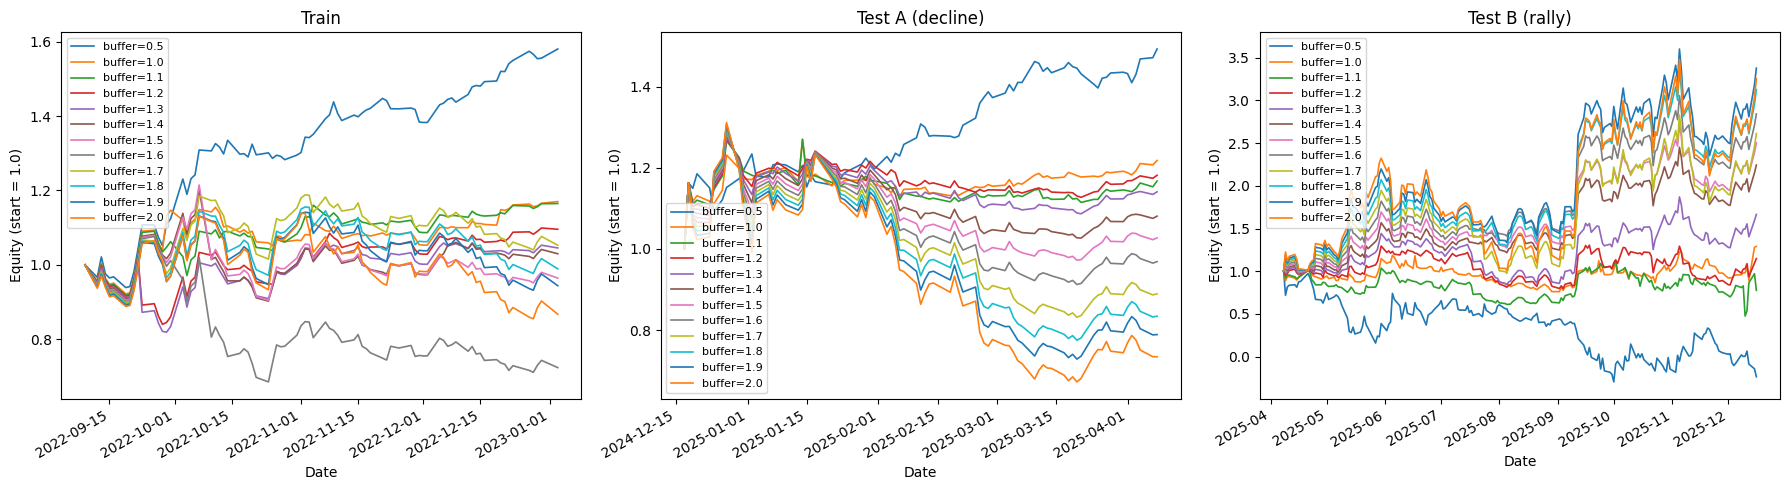

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, win_name, title in zip(axes, ["train", "testA", "testB"], ["Train", "Test A (decline)", "Test B (rally)"]):
    for buffer in BUFFERS:
        curves[(buffer, win_name)].plot(ax=ax, label=f"buffer={buffer}", linewidth=1.2)
    ax.set_title(title)
    ax.set_ylabel("Equity (start = 1.0)")
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Sanity checks

In [12]:
for (buffer, win_name), eq in curves.items():
    assert eq.isna().sum() == 0, f"buffer={buffer}/{win_name}: equity has NaNs"
assert len(buffer_results) == len(BUFFERS) * len(WINDOWS)

print("Lever 4 sanity checks passed.")
print(f"\nBUFFER_WINNER: {BUFFER_WINNER}")

Lever 4 sanity checks passed.

BUFFER_WINNER: 1.0
